# Exploración de datos — crypto-quant-desk

Fase 0.5: calidad de datos + EDA sobre el universo de activos (`config.UNIVERSE`: BTC, ETH, SOL, BNB, LTC).

Este notebook solo **llama** a funciones ya testeadas en `data/quality.py` y `eda/eda_report.py` — no reimplementa lógica acá.

Preguntas guía:
1. ¿Los retornos tienen colas más gordas que una normal?
2. ¿El precio es estacionario? ¿Y el retorno?
3. ¿Hay clustering de volatilidad (evidencia de efecto ARCH)?
4. ¿Qué activos correlacionan más entre sí (candidatos a pares para la Fase 2)?

In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    """Busca hacia arriba el directorio que contiene config.py, sin
    hardcodear rutas: funciona tanto si el notebook se ejecuta con cwd
    en `eda/` como si se ejecuta desde la raíz del repo."""
    for parent in [start, *start.parents]:
        if (parent / "config.py").exists():
            return parent
    raise RuntimeError(f"No se encontró la raíz del repo (config.py) desde {start}")


REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
import logging

import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

from config import UNIVERSE
from data.loaders import get_prices
from data.quality import validate_ohlcv
from signals.returns import log_returns
from eda.eda_report import (
    FIGURES_DIR,
    adf_test,
    correlation_matrix,
    descriptive_stats,
    ljung_box_squared,
    plot_acf_returns,
    plot_price_log,
    plot_qq,
    plot_returns_histogram,
    plot_rolling_volatility,
)

## 1. Carga de datos

Se usa `source="coinmetrics"` para que el notebook sea **100% reproducible offline** (no depende de que Binance esté accesible desde el entorno que lo ejecuta). Recordar que CoinMetrics es una fuente de solo-cierre: OHLC = close y `volume` queda en NaN (ver `data/loaders.py`).

Para correr el notebook con OHLCV real de Binance, descomentar la línea alternativa de abajo.

In [3]:
prices = {asset: get_prices(asset, source="coinmetrics") for asset in UNIVERSE}

# Alternativa con datos reales de Binance (requiere red, no reproducible offline):
# prices = {asset: get_prices(asset, source="binance") for asset in UNIVERSE}

pd.DataFrame(
    {
        asset: [len(df), df.index.min().date(), df.index.max().date()]
        for asset, df in prices.items()
    },
    index=["n_filas", "fecha_inicio", "fecha_fin"],
).T

INFO data.loaders: Caché leída desde 'C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\crypto-quant-desk\data\cache\BTC_coinmetrics_1d.parquet' (3430 filas)


INFO data.loaders: Caché leída desde 'C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\crypto-quant-desk\data\cache\ETH_coinmetrics_1d.parquet' (3430 filas)


INFO data.loaders: Caché leída desde 'C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\crypto-quant-desk\data\cache\SOL_coinmetrics_1d.parquet' (7 filas)


INFO data.loaders: Caché leída desde 'C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\crypto-quant-desk\data\cache\BNB_coinmetrics_1d.parquet' (3235 filas)


INFO data.loaders: Caché leída desde 'C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\crypto-quant-desk\data\cache\LTC_coinmetrics_1d.parquet' (3430 filas)


,n_filas,fecha_inicio,fecha_fin
BTC,3430,2017-01-01,2026-05-23
ETH,3430,2017-01-01,2026-05-23
SOL,7,2026-05-18,2026-05-24
BNB,3235,2017-07-15,2026-05-23
LTC,3430,2017-01-01,2026-05-23


## 2. Calidad de datos

`validate_ohlcv` es de solo lectura: nunca modifica los DataFrames cargados arriba, solo reporta hallazgos (gaps, outliers de retorno, precios inválidos, tramos planos, etc.).

In [4]:
quality_reports = {asset: validate_ohlcv(df, activo=asset) for asset, df in prices.items()}

for asset, report in quality_reports.items():
    print(report.resumen())

INFO data.quality: [BTC] 3430 filas (2017-01-01 00:00:00+00:00 a 2026-05-23 00:00:00+00:00) | 0 duplicados | 0 gaps | 0 filas con precio<=0 | 0 filas con volumen<0 | 31 outliers de retorno | 0 tramos planos | 2 warnings


INFO data.quality: [ETH] 3430 filas (2017-01-01 00:00:00+00:00 a 2026-05-23 00:00:00+00:00) | 0 duplicados | 0 gaps | 0 filas con precio<=0 | 0 filas con volumen<0 | 30 outliers de retorno | 0 tramos planos | 2 warnings


INFO data.quality: [SOL] 7 filas (2026-05-18 00:00:00+00:00 a 2026-05-24 00:00:00+00:00) | 0 duplicados | 0 gaps | 0 filas con precio<=0 | 0 filas con volumen<0 | 0 outliers de retorno | 0 tramos planos | 1 warnings


INFO data.quality: [BNB] 3235 filas (2017-07-15 00:00:00+00:00 a 2026-05-23 00:00:00+00:00) | 0 duplicados | 0 gaps | 0 filas con precio<=0 | 0 filas con volumen<0 | 64 outliers de retorno | 0 tramos planos | 2 warnings


INFO data.quality: [LTC] 3430 filas (2017-01-01 00:00:00+00:00 a 2026-05-23 00:00:00+00:00) | 0 duplicados | 0 gaps | 0 filas con precio<=0 | 0 filas con volumen<0 | 31 outliers de retorno | 0 tramos planos | 2 warnings


[BTC] 3430 filas (2017-01-01 00:00:00+00:00 a 2026-05-23 00:00:00+00:00) | 0 duplicados | 0 gaps | 0 filas con precio<=0 | 0 filas con volumen<0 | 31 outliers de retorno | 0 tramos planos | 2 warnings
[ETH] 3430 filas (2017-01-01 00:00:00+00:00 a 2026-05-23 00:00:00+00:00) | 0 duplicados | 0 gaps | 0 filas con precio<=0 | 0 filas con volumen<0 | 30 outliers de retorno | 0 tramos planos | 2 warnings
[SOL] 7 filas (2026-05-18 00:00:00+00:00 a 2026-05-24 00:00:00+00:00) | 0 duplicados | 0 gaps | 0 filas con precio<=0 | 0 filas con volumen<0 | 0 outliers de retorno | 0 tramos planos | 1 warnings
[BNB] 3235 filas (2017-07-15 00:00:00+00:00 a 2026-05-23 00:00:00+00:00) | 0 duplicados | 0 gaps | 0 filas con precio<=0 | 0 filas con volumen<0 | 64 outliers de retorno | 0 tramos planos | 2 warnings
[LTC] 3430 filas (2017-01-01 00:00:00+00:00 a 2026-05-23 00:00:00+00:00) | 0 duplicados | 0 gaps | 0 filas con precio<=0 | 0 filas con volumen<0 | 31 outliers de retorno | 0 tramos planos | 2 warnings

In [5]:
# Detalle de warnings por activo, para inspeccionar hallazgos específicos.
for asset, report in quality_reports.items():
    if report.warnings:
        print(f"\n{asset}:")
        for w in report.warnings:
            print(f"  - {w}")


BTC:
  - 3430 filas con OHLC degenerado (open=high=low=close, típico de fuentes de solo-cierre); se omitió el chequeo high>=low / close-en-rango en esas filas
  - 31 outliers de retorno (|log_retorno - mediana| > 8.0*MAD)

ETH:
  - 3430 filas con OHLC degenerado (open=high=low=close, típico de fuentes de solo-cierre); se omitió el chequeo high>=low / close-en-rango en esas filas
  - 30 outliers de retorno (|log_retorno - mediana| > 8.0*MAD)

SOL:
  - 7 filas con OHLC degenerado (open=high=low=close, típico de fuentes de solo-cierre); se omitió el chequeo high>=low / close-en-rango en esas filas

BNB:
  - 3235 filas con OHLC degenerado (open=high=low=close, típico de fuentes de solo-cierre); se omitió el chequeo high>=low / close-en-rango en esas filas
  - 64 outliers de retorno (|log_retorno - mediana| > 8.0*MAD)

LTC:
  - 3430 filas con OHLC degenerado (open=high=low=close, típico de fuentes de solo-cierre); se omitió el chequeo high>=low / close-en-rango en esas filas
  - 31 outlier

**Nota de lectura:** un conteo alto de `gaps` en una fuente diaria no necesariamente implica datos faltantes reales — puede reflejar cómo cada fuente reporta su histórico. Los outliers de retorno se reportan (método MAD) pero **no se eliminan acá**: para aplicar una política de saneamiento explícita, ver `data.quality.clean_ohlcv`.

## 3. Retornos y estadística descriptiva

Se trabaja con log-retornos (`signals.returns.log_returns`), escala decimal, consistente con el resto del proyecto.

In [6]:
returns = {asset: log_returns(df["close"]) for asset, df in prices.items()}

stats_table = pd.concat([descriptive_stats(r, name=a) for a, r in returns.items()])
stats_table

,n,media,std,skew,kurtosis_exceso,min,max,q01,q05,q25,q50,q75,q95,q99
BTC,3429,0.001266,0.036058,-0.657080,11.888237,-0.470563,0.224053,-0.105756,-0.056165,-0.013432,0.001217,0.017042,0.057032,0.103672
ETH,3429,0.001620,0.048467,-0.317686,9.716896,-0.565614,0.300615,-0.140329,-0.071110,-0.020111,0.000933,0.022399,0.074937,0.138705
SOL,6,0.000772,0.019233,-0.960261,-0.151005,-0.030712,0.019541,-0.029805,-0.026177,-0.009120,0.007240,0.013733,0.018130,0.019259
BNB,3234,0.002799,0.054754,1.289152,23.045225,-0.531779,0.685585,-0.138635,-0.070301,-0.017222,0.001540,0.021351,0.078881,0.173109
LTC,3429,0.000723,0.052218,0.561205,12.274657,-0.458770,0.556750,-0.138470,-0.078362,-0.022642,0.000111,0.023009,0.079581,0.142756


**¿Colas gordas?** Comparar `kurtosis_exceso` contra 0 (una normal tiene kurtosis exceso 0): valores marcadamente positivos indican colas más gordas que una normal — el diagnóstico clásico para series financieras, y la razón por la que más adelante (Fase 1b) se usa una t-Student en el GARCH en vez de una normal. El histograma + KDE y el QQ-plot generados en la sección 6 muestran esto visualmente por activo.

## 4. Estacionariedad: precio vs. retorno (test ADF)

Se corre el test Augmented Dickey-Fuller sobre el **nivel de precio** y sobre el **retorno** de cada activo, para ilustrar por qué se modela sobre retornos.

In [7]:
adf_rows = []
for asset, df in prices.items():
    adf_price = adf_test(df["close"])
    adf_ret = adf_test(returns[asset])
    adf_rows.append(
        {
            "activo": asset,
            "precio_p_valor": adf_price["p_valor"],
            "precio_estacionario": adf_price["es_estacionaria"],
            "retorno_p_valor": adf_ret["p_valor"],
            "retorno_estacionario": adf_ret["es_estacionaria"],
        }
    )
adf_table = pd.DataFrame(adf_rows).set_index("activo")
adf_table

,precio_p_valor,precio_estacionario,retorno_p_valor,retorno_estacionario
activo,,,,
BTC,0.715493,False,0.000000e+00,True
ETH,0.212980,False,5.570089e-29,True
SOL,0.095840,False,0.000000e+00,True
BNB,0.565296,False,2.149088e-23,True
LTC,0.004433,True,9.382587e-30,True


**¿Estacionariedad en precio vs. retorno?** Lo esperable en un activo tipo random walk es `precio_estacionario = False` (raíz unitaria: el precio no revierte a una media, típico de un paseo aleatorio con tendencia) y `retorno_estacionario = True` (el retorno sí fluctúa alrededor de una media estable). Revisar la tabla de arriba fila por fila contra esta expectativa — es la justificación estadística de por qué toda la Fase 1 modela sobre retornos y no sobre el nivel de precio.

## 5. Clustering de volatilidad (Ljung-Box sobre retornos²)

In [8]:
lb_rows = []
for asset, r in returns.items():
    lb = ljung_box_squared(r, lags=20)
    lb_rows.append(
        {
            "activo": asset,
            "p_valor": lb["p_valor"],
            "hay_clustering_volatilidad": lb["hay_clustering_volatilidad"],
        }
    )
lb_table = pd.DataFrame(lb_rows).set_index("activo")
lb_table

WARNING eda.eda_report: ljung_box_squared: se pidieron 20 lags pero solo hay 6 observaciones válidas; se usan 5 lags


,p_valor,hay_clustering_volatilidad
activo,,
BTC,9.566040e-23,True
ETH,7.036325e-55,True
SOL,6.166610e-01,False
BNB,5.083631e-207,True
LTC,6.945502e-40,True


**¿Clustering de volatilidad?** `hay_clustering_volatilidad = True` (p-valor bajo) es evidencia de efecto ARCH: los retornos al cuadrado están autocorrelacionados, es decir, la varianza condicional cambia en el tiempo (períodos de calma seguidos de períodos de turbulencia). Es la motivación directa para modelar la volatilidad con GARCH en la Fase 1b en vez de asumir volatilidad constante. El gráfico de volatilidad rolling (sección 6) muestra esto visualmente.

## 6. Matriz de correlación (candidatos a pares)

In [9]:
corr = correlation_matrix(returns)
corr.style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1).format("{:.2f}")

,BTC,ETH,SOL,BNB,LTC
BTC,1.00,0.97,-0.68,0.81,0.84
ETH,0.97,1.00,-0.72,0.81,0.84
SOL,-0.68,-0.72,1.00,-0.31,-0.42
BNB,0.81,0.81,-0.31,1.00,0.59
LTC,0.84,0.84,-0.42,0.59,1.00


In [10]:
# Par más correlacionado (excluyendo la diagonal), candidato natural
# a testear por cointegración en la Fase 2 (stat-arb).
off_diagonal = corr.where(~np.eye(len(corr), dtype=bool)).unstack().dropna()
top_pair = off_diagonal.abs().sort_values(ascending=False).index[0]
print(f"Par más correlacionado: {top_pair[0]}-{top_pair[1]} (correlación = {corr.loc[top_pair]:.3f})")

Par más correlacionado: BTC-ETH (correlación = 0.972)


**¿Qué activos correlacionan más?** La matriz de arriba (y el par destacado) da el punto de partida para elegir candidatos a pares en la Fase 2: una correlación alta es una condición necesaria pero NO suficiente para cointegración — ahí se testeará formalmente (Engle-Granger / Johansen) antes de operar cualquier par.

## 7. Figuras

Cada función de ploteo guarda directamente a `eda/figures/` (no muestra nada por sí misma, para poder correr este notebook headless); acá se generan todas y se muestra una de ejemplo.

In [11]:
for asset, df in prices.items():
    plot_price_log(df["close"], asset)
    plot_returns_histogram(returns[asset], asset)
    plot_qq(returns[asset], asset)
    plot_acf_returns(returns[asset], asset)
    plot_rolling_volatility(returns[asset], asset)

print(f"Figuras guardadas en {FIGURES_DIR}")

INFO eda.eda_report: Figura guardada en 'C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\crypto-quant-desk\eda\figures\BTC_price_log.png'


INFO eda.eda_report: Figura guardada en 'C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\crypto-quant-desk\eda\figures\BTC_returns_hist.png'


INFO eda.eda_report: Figura guardada en 'C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\crypto-quant-desk\eda\figures\BTC_qq.png'


INFO eda.eda_report: Figura guardada en 'C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\crypto-quant-desk\eda\figures\BTC_acf.png'


INFO eda.eda_report: Figura guardada en 'C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\crypto-quant-desk\eda\figures\BTC_rolling_vol.png'


...

INFO eda.eda_report: Figura guardada en 'C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\crypto-quant-desk\eda\figures\LTC_returns_hist.png'


INFO eda.eda_report: Figura guardada en 'C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\crypto-quant-desk\eda\figures\LTC_qq.png'


INFO eda.eda_report: Figura guardada en 'C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\crypto-quant-desk\eda\figures\LTC_acf.png'


INFO eda.eda_report: Figura guardada en 'C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\crypto-quant-desk\eda\figures\LTC_rolling_vol.png'


Figuras guardadas en C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\crypto-quant-desk\eda\figures


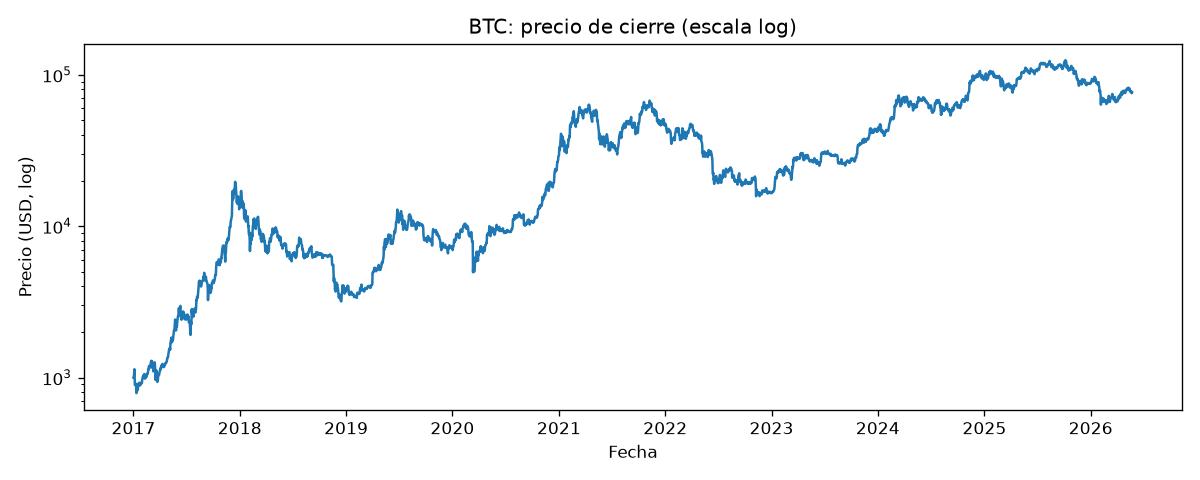

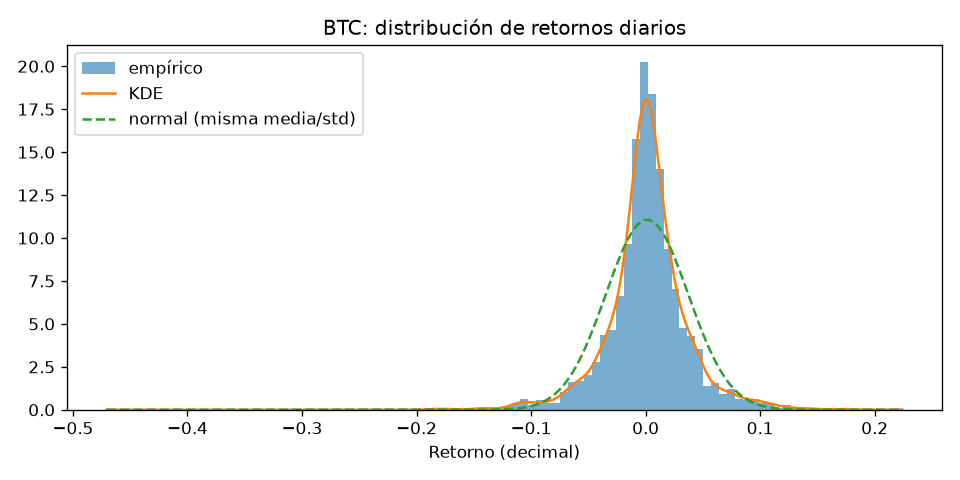

In [12]:
from IPython.display import Image, display

# Ejemplo: precio de BTC en escala log + distribución de retornos.
display(Image(filename=str(FIGURES_DIR / "BTC_price_log.png")))
display(Image(filename=str(FIGURES_DIR / "BTC_returns_hist.png")))

## 8. Resumen de hallazgos

- **Calidad de datos:** ver sección 2 — reportes de gaps, outliers de retorno y precios inválidos por activo (CoinMetrics community es una fuente de solo-cierre, así que `volume` en NaN es esperado, no un problema de calidad).
- **Colas gordas:** ver `kurtosis_exceso` en la tabla de la sección 3 y los histogramas/QQ-plots de la sección 7 — comparar contra 0.
- **Estacionariedad:** ver tabla ADF de la sección 4 — se espera precio no estacionario, retorno sí estacionario.
- **Clustering de volatilidad:** ver tabla Ljung-Box de la sección 5 y los gráficos de volatilidad rolling en `eda/figures/` — motiva usar GARCH en la Fase 1b en vez de volatilidad constante.
- **Candidatos a pares:** ver matriz de correlación de la sección 6 — el par más correlacionado es el primer candidato a testear por cointegración en la Fase 2, pero correlación alta no implica cointegración por sí sola.